In [1]:
import numpy as np
from mnist import MNIST #Để đọc dữ liệu từ MNIST(pip install python-mnist)
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from display_network import * #Để hiển thị nhiều bức ảnh chữ số cùng 1 lúc

## Thực hiện thuật toán K-means trên 10k chữ số

In [2]:
mndata = MNIST('E:\\LapTrinh\\PYTHON\\AI\Machine Learning\\K-meansApplication\\MNIST') #path to your MNIST folder 
mndata.load_testing()
X = mndata.test_images
X0 = np.asarray(X)[:1000, :] / 256.0
X = X0

K = 10
kmeans = KMeans(n_clusters = K).fit(X)

pred_label = kmeans.predict(X)
print(pred_label)

[1 8 7 6 9 7 1 9 3 2 6 4 1 6 5 0 9 1 0 9 2 3 4 3 9 6 9 9 6 5 0 5 0 4 2 8 1
 5 8 5 5 1 1 7 5 3 5 8 9 9 3 0 3 0 4 3 9 7 9 7 9 2 1 8 2 1 4 9 0 6 1 6 8 2
 5 1 0 1 7 2 9 3 8 9 9 9 2 0 4 7 0 3 2 0 5 9 5 7 3 9 4 6 0 9 9 9 8 7 9 1 3
 7 5 9 1 1 1 9 1 2 0 3 1 3 1 9 6 1 2 3 3 3 0 1 2 5 3 7 4 2 3 9 0 7 2 5 2 8
 3 7 9 9 1 0 5 3 4 3 0 5 1 3 0 9 4 0 1 7 5 1 9 2 8 0 8 7 5 2 5 0 5 0 3 6 3
 1 8 0 6 5 7 5 3 9 6 5 5 3 1 8 0 4 7 5 7 0 1 0 8 9 9 1 9 5 9 3 0 3 1 3 9 8
 2 1 7 8 2 1 7 1 3 7 0 2 1 9 8 8 9 5 0 0 2 1 7 3 6 8 9 8 9 5 9 3 1 1 8 3 8
 4 2 7 1 1 1 5 3 5 0 6 0 6 5 1 9 9 7 2 8 5 8 1 1 1 9 8 3 9 7 0 9 8 9 8 6 9
 6 6 8 0 7 1 5 1 1 6 8 1 1 0 0 6 6 0 5 9 3 7 0 0 5 2 9 0 3 2 8 6 1 5 5 8 5
 0 0 0 9 1 0 3 3 9 5 0 0 5 3 3 7 1 5 0 6 4 7 2 0 5 1 1 9 4 1 7 0 3 4 0 3 0
 1 8 6 2 2 3 1 7 5 9 6 1 0 1 4 7 3 8 7 1 4 2 3 5 1 0 8 0 9 9 8 0 0 1 8 9 0
 6 0 5 9 7 0 1 9 1 5 1 8 5 1 8 1 8 6 9 1 5 1 8 7 8 9 1 1 2 2 0 1 3 6 3 0 3
 2 4 3 2 2 0 0 0 8 0 9 7 7 3 2 6 1 4 4 4 2 2 2 8 2 0 2 1 4 5 2 9 5 8 3 0 7
 9 9 7 1 6 2 9 1 7 4 3 8 

In [3]:
print(type(kmeans.cluster_centers_.T))
print(kmeans.cluster_centers_.T.shape)

<class 'numpy.ndarray'>
(784, 10)


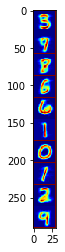

In [4]:
A = display_network(kmeans.cluster_centers_.T, K, 1)

#cmap để ánh xạ dữ liệu vô hướng với màu sắc (viridis, jet, gray)
#aspect (auto, equal)
f1 = plt.imshow(A, interpolation = "nearest", cmap = "jet", aspect = 'equal')
f1.axes.get_xaxis().set_visible(True) #True, False để hiển thị trục tọa độ
f1.axes.get_yaxis().set_visible(True)
plt.show()
#plt.savefig("a1.png", bbox_inches = "tight")

In [5]:
#A colormap and a normalization instance
cmap = plt.cm.jet
norm = plt.Normalize(vmin = A.min(), vmax = A.max())

#Map the normalized data to colors
#Image is now RGBA (512x512x4) 
image = cmap(norm(A))

plt.imsave("aa.png", image)

### Chọn một vài ảnh từ mỗi cluster

In [6]:
print(type(pred_label))
print(pred_label.shape)
print(type(X0))

<class 'numpy.ndarray'>
(1000,)
<class 'numpy.ndarray'>


In [7]:
N0 = 20;
X1 = np.zeros((N0 * K, 784))
X2 = np.zeros((N0 * K, 784))

for k in range(K):
    Xk = X0[pred_label == k, :]

    center_k = [kmeans.cluster_centers_[k]]
    neigh = NearestNeighbors(N0).fit(Xk)
    dist, nearest_id  = neigh.kneighbors(center_k, N0)
    
    X1[N0 * k: N0 * k + N0, :] = Xk[nearest_id, :]
    X2[N0 * k: N0 * k + N0, :] = Xk[:N0, :]

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\utils\validation.py:67: FutureWarning: Pass n_neighbors=20 as keyword args. From version 0.25 passing these as positional arguments will result in an error
  warnings.warn("Pass {} as keyword args. From version 0.25 "
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\utils\validation.py:67: FutureWarning: Pass n_neighbors=20 as keyword args. From version 0.25 passing these as positional arguments will result in an error
  warnings.warn("Pass {} as keyword args. From version 0.25 "
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\utils\validation.py:67: FutureWarning: Pass n_neighbors=20 as keyword args. From version 0.25 passing these as positional arguments will result in an error
  warnings.warn("Pass {} as keyword args. From version 0.25 "
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\utils\validation.py:67: FutureWarning: Pass n_neighbors=20 as keyword args. From version 0.25 passing these as positional arguments will resul

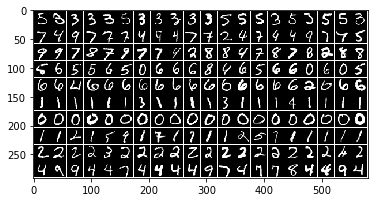

In [8]:
plt.axis("on")
A = display_network(X2.T, K, N0)
f2 = plt.imshow(A, interpolation="nearest")
plt.gray()
plt.show()

#import scipy.misc
#scipy.misc.imsave('bb.png', A)

#plt.axis('off')
#A = display_network(X1.T, 10, N0)
#scipy.misc.imsave('cc.png', A)
#f2 = plt.imshow(A, interpolation='nearest' )
#plt.gray()

#plt.show()

## Segmentation and Compression

In [9]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

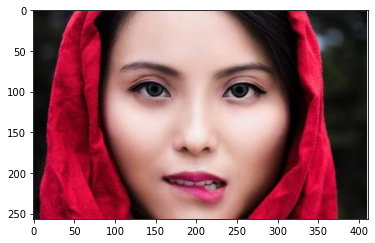

In [15]:
img = mpimg.imread("girl.jpg")
imgplot = plt.imshow(img)
plt.axis("on")
plt.show()

In [21]:
X = img.reshape((img.shape[0] * img.shape[1], img.shape[2]))
#Chiều 1 là trên xuống, chiều 2 từ trái sang, chiều 3 là vector gồm 3 màu RGB
print(img.shape)
print(type(X))
print(X.shape)

(257, 412, 3)
<class 'numpy.ndarray'>
(105884, 3)


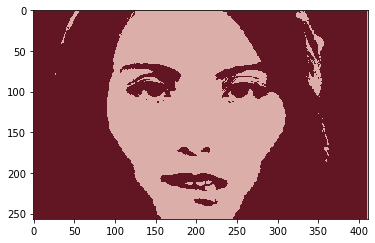

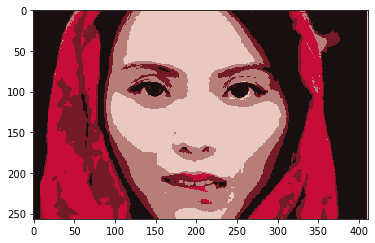

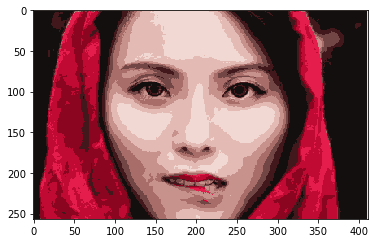

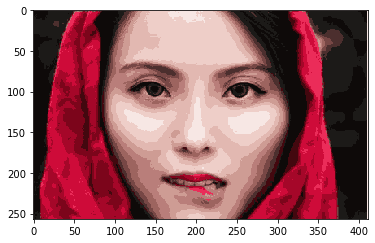

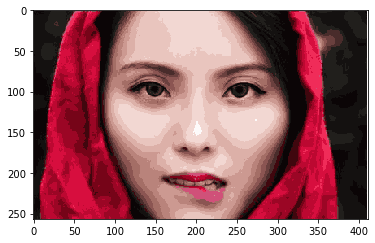

In [12]:
#Số lượng các clusters khác nhau
for K in [2, 5, 10, 15, 20]:
    kmeans = KMeans(n_clusters = K).fit(X)
    label = kmeans.predict(X)

    img4 = np.zeros_like(X)
    #Replace each pixel by its center
    for k in range(K):
        img4[label == k] = kmeans.cluster_centers_[k]
    #Reshape and display output image
    img5 = img4.reshape((img.shape[0], img.shape[1], img.shape[2]))
    plt.imshow(img5, interpolation = "nearest")
    plt.axis("on")
    plt.show()

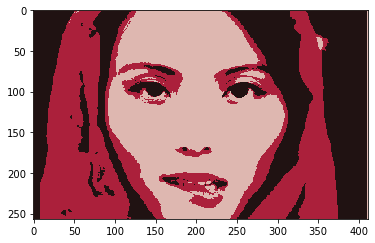

In [13]:
for K in [3]:
    kmeans = KMeans(n_clusters = K).fit(X)
    label = kmeans.predict(X)

    img4 = np.zeros_like(X)
    #Replace each pixel by its center
    for k in range(K):
        img4[label == k] = kmeans.cluster_centers_[k]
    #Reshape and display output image
    img5 = img4.reshape((img.shape[0], img.shape[1], img.shape[2]))
    plt.imshow(img5, interpolation = "nearest")
    plt.axis("on")
    plt.show()

### Sau khi tìm đc các clusters, thay gtri của mỗi pixel bằng center của cluster chứa có, và đc kết quả như trên
#### Ba màu hồng, đen và màu da đã đc phân nhóm. Và khuôn mặt có thể tách ra từ phần màu da(và vùng bên trong nó)

## Nén dữ liệu, ảnh

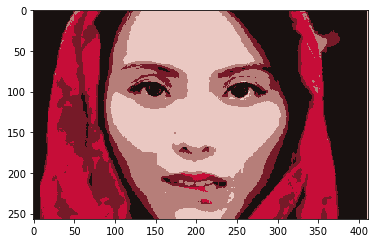

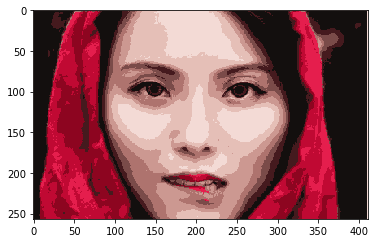

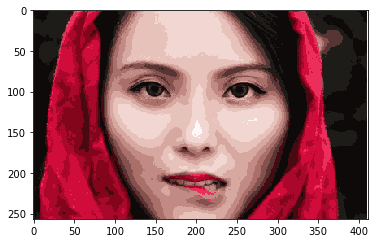

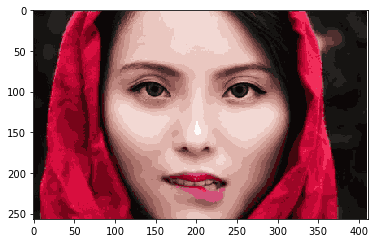

In [14]:
for K in [5, 10, 15, 20]:
    kmeans = KMeans(n_clusters = K).fit(X)
    label = kmeans.predict(X)

    img4 = np.zeros_like(X)
    # replace each pixel by its center
    for k in range(K):
        img4[label == k] = kmeans.cluster_centers_[k]
    # reshape and display output image
    img5 = img4.reshape((img.shape[0], img.shape[1], img.shape[2]))
    plt.imshow(img5, interpolation = "nearest")
    plt.axis("on")
    plt.show()